# Import Colop

In [1]:
import pandas as pd
import numpy as np
import plotly_express as px

# Get raw text

In [2]:
raw_lines = open("../../textos/colop-pk.txt", "r").readlines()

In [3]:
part_num = 0
chap_num = 0
line_num = 0
new_lines = []
part_name = ''
parts = []
for line in raw_lines:
    if "<PARTE>" in line:
        part_num += 1
        part_name = line.strip().replace("<PARTE>", "")
        chap_num = 0
    if "<CAPITULO>" in line:
        chap_num += 1
        line_num = 0
        parts.append((part_num, part_name, chap_num, line.strip().replace("<CAPITULO>","")))
    line_num += 1
    new_lines.append((part_num, chap_num, line_num, line))

In [4]:
DIV = pd.DataFrame(parts)
DIV.columns = ['parte', 'parte_nombre', 'capit', 'capit_nombre']

In [5]:
DIV.head()

,parte,parte_nombre,capit,capit_nombre
0,1,NAB'E,1,ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I'
1,1,NAB'E,2,ARE UTZIJOXIK WA'E
2,1,NAB'E,3,TA XWINAQIR K'U RI ULEW KUMAL
3,1,NAB'E,4,"K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ,"
4,1,NAB'E,5,K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...


In [6]:
PARTE = DIV.value_counts(['parte','parte_nombre']).to_frame('n').reset_index().set_index('parte').sort_index()

In [7]:
PARTE

,parte_nombre,n
parte,,
1,NAB'E,6
2,UKAB',5
3,ROX,14
4,UKAJ,11
5,RO',15


In [8]:
DOC = DIV.set_index(['parte','capit'])

In [9]:
DOC

parte_nombre                                       capit_nombre
parte capit                                                                
1     1            NAB'E            ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I'
      2            NAB'E                                 ARE UTZIJOXIK WA'E
      3            NAB'E                      TA XWINAQIR K'U RI ULEW KUMAL
      4            NAB'E          K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ,
      5            NAB'E  K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...
      6            NAB'E                          K'ATE K'UT KIK'ISIK CHIK,
2     1            UKAB'         ARE K'UT XA JUB'IQ' SAQNATANOJ UWACH ULEW,
      2            UKAB'  K'EJE K'UT XCHIQAB'IJ CHIK TA XKAMIK WUQUB' KA...
      3            UKAB'               WA'E CHI K'UTE UB'ANOJ CHIK SIPAKNA,
      4            UKAB'                             ARE CHIK UCH'AKATAJIK,
      5            UKAB'                    JUN CHI K'UT XCHIQAB'IJ UB'IXIK
3     1              ROX  ARE CHI K'UT XCHIQAB'IJ CHIK UB'I' KIQAJAW RI ...
      2              ROX  ARE CHI K'UT XCHIQAB'IJ CHIK KIB'E'IK CHI XIB'...
      3              ROX  K'ATE PUCH TA XEB'EK JUN JUNAJPU, WUQUB' JUNAJPU.
      4              ROX                K'ATE K'UT XE'OPONIK PA Q'EQUMA JA,
      5              ROX                 WA CHI K'UTE UTZIJOXIK JUN Q'APOJ,
      6              ROX    ARE K'UTE K'O RI UCHUCH JUN B'ATZ', JUN CHOWEN,
      7              ROX  ARE CHIK XCHIQATZIJOJ KALAXIK JUNAJPU, SXB'ALA...
      8              ROX   TA XEB'E K'UT CHILA' CHUXE' CHE', Q'ANTE' UB'I';
      9              ROX               K'ATE K'UT XUKAQ'AT ULA CH'O RI KIK'
      10             ROX  TA XEPE K'UT NIMA JOK K'U KIB'E RI K'AJOLAB' C...
      11             ROX                                     TA XEB'E K'UT,
      12             ROX                 K'ATE K'UT TA XE'OK PA Q'EQUMA JA,
      13             ROX  ARE K'UT WA'E KINAB'AL, KIKAMIK JUNAJPU, XB'AL...
      14             ROX  K'ATE PUCH URAYINIK, UMALINIK PU KIK'UX AJAWAB...
4     1             UKAJ  WA'E K'UT UTIKERIK TA XNA'OJIX WINAQ, TA XTZUK...
      2             UKAJ        WA'E KIB'I NAB'E WINAQ XETZ'AQIK, XEB'ITIK:
      3             UKAJ            ARE K'UT UXE' QECH, RI OJ K'ECHE' WINAQ
      4             UKAJ                         ARE K'UT UB'I' JUYUB' WA',
      5             UKAJ    WA'E K'UTE' USAQIRIK, UWACHINIK PUCH Q'IJ, IK',
      6             UKAJ                              WA K'UTE' KIK'ATONIK,
      7             UKAJ  WA'E UTIKARIK CHIK RELEQ'AXIK WINAQ, AMAQ' kum...
      8             UKAJ                   ARE K'U WA' UK'AMIK UNA'OJ AMAQ'
      9             UKAJ                                 K'ATE PUCH XEB'EK,
      10            UKAJ           WA'E K'UTE KIMOLOWIK KIB' KONOJEL AMAQ',
      11            UKAJ  ARE CHIK WI XCHIQAB'IJ CHIK KIKAMIK B'alam Kit...
5     1              RO'                    K'ATE PUCH TA XKIK'UXLAJ KIB'IK
      2              RO'                            TA XE'UL CHI K'U CHIRI'
      3              RO'        WA'E K'UTE KIB'I' AJAWAB' CHUWACH KAWIQIB'.
      4              RO'       ARE CHI K'U AJAWAB' WA' CHUWACH NIJA'IB'AB':
      5              RO'                     ARE CHI K'UT AJAW K'ICHE' WA'.
      6              RO'     KA'IB' CHINAMIT CHI NAY PUCH SAQIKIB' AJAWAB':
      7              RO'           WA' CHI K'UTE KIB'I' CHIK UWAQ LE' AJAW,
      8              RO'    ARE K'UT XCHIQAB'IJ CHIK UB'I' ROCHOCH KAB'AWIL
      9              RO'  ARE CHI K'UT XCHIQACHOLO ULE'EL AJAWAB' RUK' K...
      10             RO'               ARE CHI XCHIQAB'IJ CHIK RE CHINAMIT,
      11             RO'   ARE UB'INA'M WI B'ELEJEB' CHINAMIT CHI KAWIQIB',
      12             RO'                          WA K'UTE RECH NIJA'IB'AB'
      13             RO'      ARE CHIK XCHIQAB'IJ RAJAWAL JUJUN CHI NIM JA:
      14             RO'                     ARE CHI K'UT RECH AJAW K'ICHE'
      15             RO'                  ARE K'U RI E OXIB'

In [10]:
lines = pd.DataFrame(new_lines, columns=['parte', 'capit', 'line_num', 'line_str']).set_index(['parte', 'capit', 'line_num'])
lines.line_str = lines.line_str.str.strip()
lines = lines[~lines.line_str.str.match("<PARTE>")]
lines.line_str = lines.line_str.str.replace("<CAPITULO>", "")

In [11]:
lines

line_str
parte capit line_num                                                  
1     1     1                  ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I'
            2                                 Waral xchiqatz'ib'aj wi,
            3                              xchiqatikib'a' wi ojer tzij
            4                                             utikarib'al,
            5         uxe'nab'al puch ronojel xb'an pa tinamit K'iche'
...                                                                ...
5     15    17                                              K'o nab'e,
            18                                    ojer, kumal ajawab'.
            19                                          Sachinaq chik.
            20             Xere k'u ri mixutzinik chi konojel K'iche',
            21                                       Sta. Cruz, ub'i'.

[6716 rows x 1 columns]

# Create DOC

In [12]:
DOC['doc_str'] = lines.groupby(['parte','capit']).line_str.apply(lambda x: ' '.join(x)).to_frame('doc_str')

In [13]:
DOC

parte_nombre                                       capit_nombre  \
parte capit                                                                   
1     1            NAB'E            ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I'   
      2            NAB'E                                 ARE UTZIJOXIK WA'E   
      3            NAB'E                      TA XWINAQIR K'U RI ULEW KUMAL   
      4            NAB'E          K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ,   
      5            NAB'E  K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...   
      6            NAB'E                          K'ATE K'UT KIK'ISIK CHIK,   
2     1            UKAB'         ARE K'UT XA JUB'IQ' SAQNATANOJ UWACH ULEW,   
      2            UKAB'  K'EJE K'UT XCHIQAB'IJ CHIK TA XKAMIK WUQUB' KA...   
      3            UKAB'               WA'E CHI K'UTE UB'ANOJ CHIK SIPAKNA,   
      4            UKAB'                             ARE CHIK UCH'AKATAJIK,   
      5            UKAB'                    JUN CHI K'UT XCHIQAB'IJ UB'IXIK   
3     1              ROX  ARE CHI K'UT XCHIQAB'IJ CHIK UB'I' KIQAJAW RI ...   
      2              ROX  ARE CHI K'UT XCHIQAB'IJ CHIK KIB'E'IK CHI XIB'...   
      3              ROX  K'ATE PUCH TA XEB'EK JUN JUNAJPU, WUQUB' JUNAJPU.   
      4              ROX                K'ATE K'UT XE'OPONIK PA Q'EQUMA JA,   
      5              ROX                 WA CHI K'UTE UTZIJOXIK JUN Q'APOJ,   
      6              ROX    ARE K'UTE K'O RI UCHUCH JUN B'ATZ', JUN CHOWEN,   
      7              ROX  ARE CHIK XCHIQATZIJOJ KALAXIK JUNAJPU, SXB'ALA...   
      8              ROX   TA XEB'E K'UT CHILA' CHUXE' CHE', Q'ANTE' UB'I';   
      9              ROX               K'ATE K'UT XUKAQ'AT ULA CH'O RI KIK'   
      10             ROX  TA XEPE K'UT NIMA JOK K'U KIB'E RI K'AJOLAB' C...   
      11             ROX                                     TA XEB'E K'UT,   
      12             ROX                 K'ATE K'UT TA XE'OK PA Q'EQUMA JA,   
      13             ROX  ARE K'UT WA'E KINAB'AL, KIKAMIK JUNAJPU, XB'AL...   
      14             ROX  K'ATE PUCH URAYINIK, UMALINIK PU KIK'UX AJAWAB...   
4     1             UKAJ  WA'E K'UT UTIKERIK TA XNA'OJIX WINAQ, TA XTZUK...   
      2             UKAJ        WA'E KIB'I NAB'E WINAQ XETZ'AQIK, XEB'ITIK:   
      3             UKAJ            ARE K'UT UXE' QECH, RI OJ K'ECHE' WINAQ   
      4             UKAJ                         ARE K'UT UB'I' JUYUB' WA',   
      5             UKAJ    WA'E K'UTE' USAQIRIK, UWACHINIK PUCH Q'IJ, IK',   
      6             UKAJ                              WA K'UTE' KIK'ATONIK,   
      7             UKAJ  WA'E UTIKARIK CHIK RELEQ'AXIK WINAQ, AMAQ' kum...   
      8             UKAJ                   ARE K'U WA' UK'AMIK UNA'OJ AMAQ'   
      9             UKAJ                                 K'ATE PUCH XEB'EK,   
      10            UKAJ           WA'E K'UTE KIMOLOWIK KIB' KONOJEL AMAQ',   
      11            UKAJ  ARE CHIK WI XCHIQAB'IJ CHIK KIKAMIK B'alam Kit...   
5     1              RO'                    K'ATE PUCH TA XKIK'UXLAJ KIB'IK   
      2              RO'                            TA XE'UL CHI K'U CHIRI'   
      3              RO'        WA'E K'UTE KIB'I' AJAWAB' CHUWACH KAWIQIB'.   
      4              RO'       ARE CHI K'U AJAWAB' WA' CHUWACH NIJA'IB'AB':   
      5              RO'                     ARE CHI K'UT AJAW K'ICHE' WA'.   
      6              RO'     KA'IB' CHINAMIT CHI NAY PUCH SAQIKIB' AJAWAB':   
      7              RO'           WA' CHI K'UTE KIB'I' CHIK UWAQ LE' AJAW,   
      8              RO'    ARE K'UT XCHIQAB'IJ CHIK UB'I' ROCHOCH KAB'AWIL   
      9              RO'  ARE CHI K'UT XCHIQACHOLO ULE'EL AJAWAB' RUK' K...   
      10             RO'               ARE CHI XCHIQAB'IJ CHIK RE CHINAMIT,   
      11             RO'   ARE UB'INA'M WI B'ELEJEB' CHINAMIT CHI KAWIQIB',   
      12             RO'                          WA K'UTE RECH NIJA'IB'AB'   
      13             RO'      ARE CHIK XCHIQAB'IJ RAJAWAL JUJU

In [14]:
# DOC = lines.groupby(['parte','capit']).line_str.apply(lambda x: ' '.join(x)).to_frame('doc_str')

In [15]:
DOC.head()

parte_nombre                                       capit_nombre  \
parte capit                                                                   
1     1            NAB'E            ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I'   
      2            NAB'E                                 ARE UTZIJOXIK WA'E   
      3            NAB'E                      TA XWINAQIR K'U RI ULEW KUMAL   
      4            NAB'E          K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ,   
      5            NAB'E  K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...   

                                                       doc_str  
parte capit                                                     
1     1      ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I' Waral ...  
      2      ARE UTZIJOXIK WA'E k'akatz'ininoq, k'akachamam...  
      3      TA XWINAQIR K'U RI ULEW KUMAL Xa kitzij xk'oje...  
      4      K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ, WINA...  
      5      K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...

In [16]:
DOC['n_chars'] = DOC.doc_str.str.len()

In [17]:
DOC['p'] = DOC.n_chars / DOC.n_chars.sum().sum()

In [18]:
round(DOC.p * 1000).astype(int).unstack(fill_value=0).style.background_gradient(axis=None)

capit,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
parte,,,,,,,,,,,,,,,
1,8,11,20,7,15,16,0,0,0,0,0,0,0,0,0
2,7,36,25,17,23,0,0,0,0,0,0,0,0,0,0
3,20,13,11,18,31,16,15,60,7,28,21,68,41,29,0
4,11,21,21,81,28,24,11,14,27,33,17,0,0,0,0
5,15,35,2,2,1,14,30,26,9,1,3,4,3,3,3


# Create TOKEN

In [99]:
TOKEN = DOC.doc_str.str.split(expand=True).stack().to_frame('token_str')
TOKEN.index.names = list(TOKEN.index.names)[:2] + ['token_num']
TOKEN['term_str'] = TOKEN.token_str.str.replace(r"[,.]+", "", regex=True).str.lower()

In [101]:
TOKEN

token_str term_str
parte capit token_num                   
1     1     0              ARE'     are'
            1              UXE'     uxe'
            2              OJER     ojer
            3              TZIJ     tzij
            4             WARAL    waral
...                         ...      ...
5     15    89          konojel  konojel
            90         K'iche',  k'iche'
            91             Sta.      sta
            92            Cruz,     cruz
            93           ub'i'.    ub'i'

[27092 rows x 2 columns]

# Vectorize

In [19]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer

In [20]:
# CountVectorizer?

In [21]:
count_engine = CountVectorizer(
    lowercase=True,
    analyzer='word',
    token_pattern=r"(?u)\b[a-z'][a-z']+\b",
    max_df=.99,
    min_df=5,    
    ngram_range = (1,1)
)

In [22]:
X = count_engine.fit_transform(DOC.doc_str)

In [23]:
DTM = pd.DataFrame(X.toarray(), 
    columns=count_engine.get_feature_names_out(), 
    index=DOC.index)

In [24]:
DTM.head()

ab'aj  achij  aj  ajam  ajaw  ajawab  ajawarem  ajb'it  ajilan  \
parte capit                                                                   
1     1          0      0   0     0     0       0         0       0       0   
      2          1      0   0     0     0       0         0       0       0   
      3          0      0   0     0     0       0         0       0       0   
      4          0      0   0     0     0       0         0       2       0   
      5          0      0   0     3     0       0         0       3       0   

             ajk'ajb  ...  xub'an  xub'ina'j  xucha'xik  xuchax  xuk'am  xul  \
parte capit           ...                                                      
1     1            0  ...       0          0          0       0       0    0   
      2            0  ...       0          0          0       0       0    1   
      3            0  ...       0          0          0       0       0    0   
      4            0  ...       0          0          0       0       0    0   
      5            0  ...       0          0          0       0       0    0   

             xuxik  xwinaqir  xya  ya  
parte capit                            
1     1          0         0    0   0  
      2          0         0    0   0  
      3          1         3    0   0  
      4          0         0    0   0  
      5          0         0    0   0  

[5 rows x 443 columns]

In [25]:
tfidf_engine = TfidfTransformer(norm='l2', use_idf=True)

In [26]:
TFIDF = pd.DataFrame(tfidf_engine.fit_transform(DTM).toarray(), columns=DTM.columns, index=DTM.index)

# Vocabulary

In [27]:
VOCAB = DTM.sum().to_frame('n')
VOCAB['n_chars'] = VOCAB.index.str.len()
VOCAB['df'] = DTM.astype(bool).sum()
VOCAB['dfidf'] = VOCAB.df * np.log2(len(DTM)/VOCAB.df)
SIGS = VOCAB.sort_values('dfidf', ascending=False).head(4000).index.to_list()

In [28]:
VOCAB.sample(10)

,n,n_chars,df,dfidf
xpetik,5,6,5,16.752486
chel,7,4,6,18.524777
jal,18,3,6,18.524777
uk'ajol,27,7,12,25.049554
kib,89,3,27,24.773522
k'axtok,8,7,6,18.524777
ke'ucha'xik,13,11,11,24.342931
kiq'ij,7,6,7,20.055493
xawi,109,4,27,24.773522
aq,6,2,5,16.752486


In [29]:
STOPW = VOCAB.df.sort_values(ascending=False).head(10).index.to_list()

In [30]:
STOPW

['are', "k'ut", 'ri', 'chik', 'ja', "k'u", 'xa', 'wi', 'ta', 'jun']

In [31]:
SIGS = list(set(SIGS) - set(STOPW))

# PCA

In [32]:
from sklearn.decomposition import TruncatedSVD as SVD

In [33]:
svd_engine = SVD(n_components=10)

In [34]:
SVD = pd.DataFrame(svd_engine.fit_transform(TFIDF), index=TFIDF.index)

In [35]:
SVD.head()

0         1         2         3         4         5  \
parte capit                                                               
1     1      0.317330  0.081059  0.155040  0.523298  0.072676 -0.126069   
      2      0.620748 -0.061622  0.123928  0.413518 -0.056856  0.022416   
      3      0.658093 -0.131468  0.108489  0.246650 -0.009071  0.081156   
      4      0.591635 -0.107312  0.092415  0.346131 -0.014631  0.098444   
      5      0.635812 -0.099332  0.066174  0.425237 -0.058223  0.062274   

                    6         7         8         9  
parte capit                                          
1     1      0.089068  0.155503  0.341920 -0.285405  
      2      0.005554  0.046030 -0.085131 -0.007602  
      3     -0.105760 -0.077973 -0.100291  0.012100  
      4     -0.008412  0.109089 -0.313886  0.085738  
      5     -0.014953 -0.053970 -0.229789  0.047254

# Cluster

In [41]:
import sys
sys.path.append("../../local_lib/")

In [43]:
from hac2 import HAC

In [44]:
# M = TFIDF[SIGS]
# M = TFIDF
M = SVD

In [45]:
metric = 'euclidean' # "euclidean", "l1", "l2", "manhattan", "cosine", or "precomputed"
linkage = 'ward' # 'ward', 'complete', 'average', 'single'

In [46]:
fig1 = HAC(M)
fig1.linkage_method = linkage
fig1.dist_metric = metric

In [47]:
fig1.color_thresh = 1.8

<Figure size 640x480 with 0 Axes>

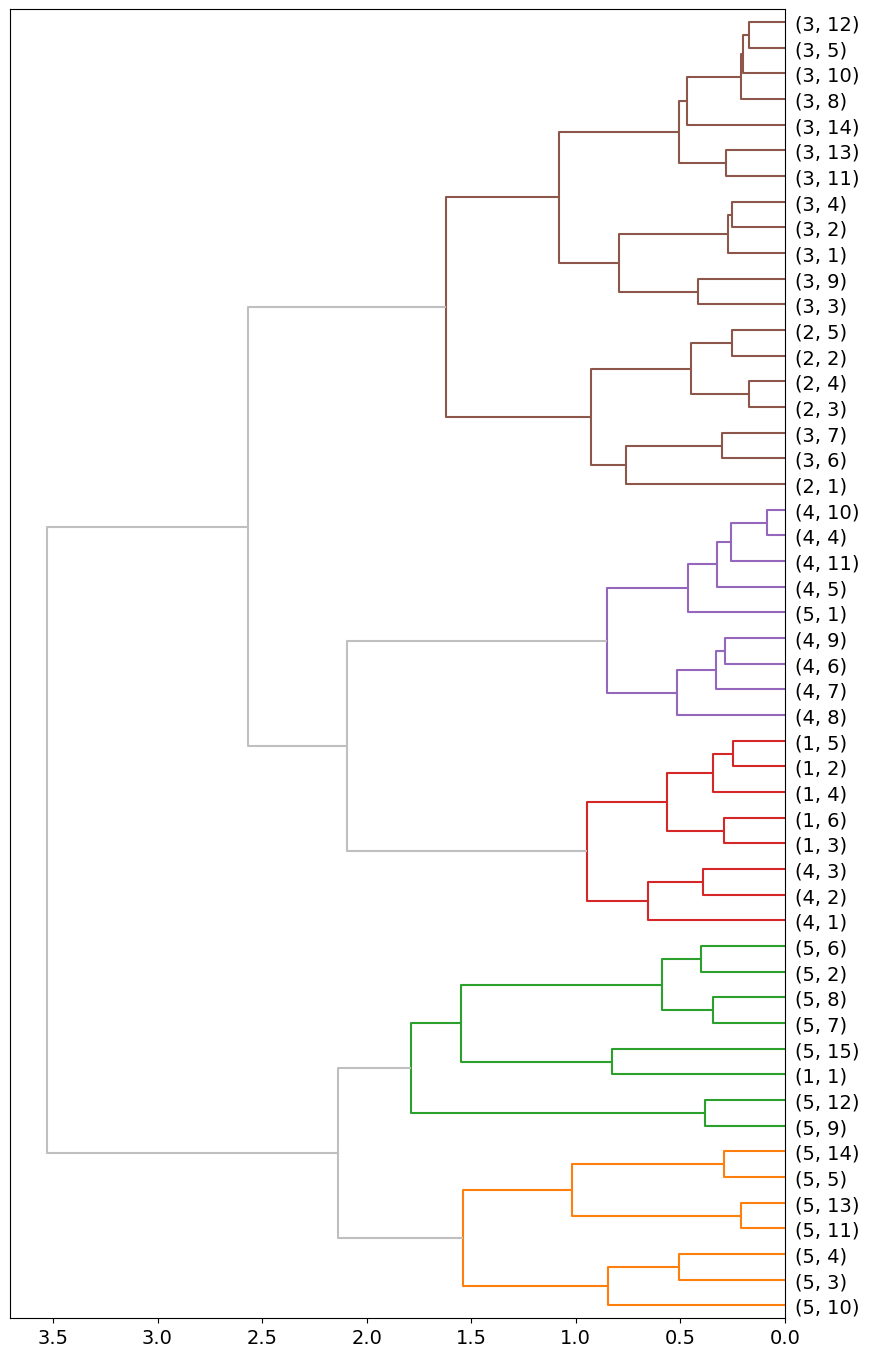

In [48]:
fig1.plot()

In [49]:
from sklearn.cluster import AgglomerativeClustering

In [50]:
n_clusters = 5

In [51]:
cluster = AgglomerativeClustering(n_clusters=n_clusters, 
    metric=metric, linkage=linkage)
DOC['label'] = (cluster.fit_predict(M)  + 1).astype(str)

In [52]:
DOC.head()

parte_nombre                                       capit_nombre  \
parte capit                                                                   
1     1            NAB'E            ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I'   
      2            NAB'E                                 ARE UTZIJOXIK WA'E   
      3            NAB'E                      TA XWINAQIR K'U RI ULEW KUMAL   
      4            NAB'E          K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ,   
      5            NAB'E  K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...   

                                                       doc_str  n_chars  \
parte capit                                                               
1     1      ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I' Waral ...     1341   
      2      ARE UTZIJOXIK WA'E k'akatz'ininoq, k'akachamam...     1825   
      3      TA XWINAQIR K'U RI ULEW KUMAL Xa kitzij xk'oje...     3396   
      4      K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ, WINA...     1219   
      5      K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...     2436   

                    p label  
parte capit                  
1     1      0.008013     1  
      2      0.010906     1  
      3      0.020293     1  
      4      0.007284     1  
      5      0.014557     1

In [53]:
LABEL = DOC.label.value_counts().to_frame('n')

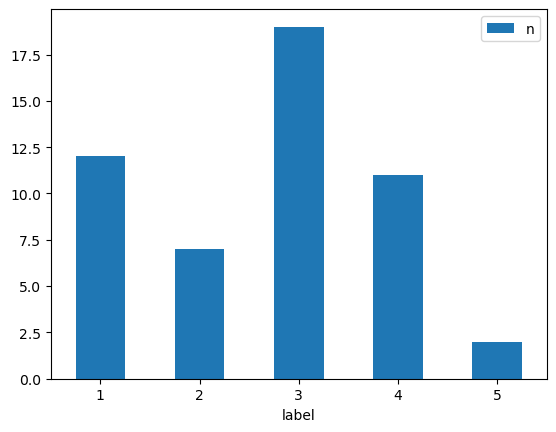

In [54]:
LABEL.sort_index().plot.bar(rot=0);

In [55]:
LABEL['color'] = pd.Series({
    '1': 'lightgray',
    '2': 'pink',
    '3': 'lightblue',
    '4': 'lightgreen',
    '5': 'lightyellow',
    '6': 'orange',
    '': 'white'
})

In [56]:
LABEL

,n,color
label,,
3,19,lightblue
1,12,lightgray
4,11,lightgreen
2,7,pink
5,2,lightyellow


In [57]:
DOC.label.unstack(fill_value='').style.map(lambda x: 'background:' + LABEL.loc[x, 'color'] if x != '' else 'background:white')

capit,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
parte,,,,,,,,,,,,,,,
1,1,1,1,1,1,1,,,,,,,,,
2,3,3,3,3,3,,,,,,,,,,
3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,
4,1,4,4,4,4,4,4,4,4,4,4,,,,
5,4,1,2,2,2,1,1,1,5,2,2,5,2,2,1


# Gloss LABEL

In [58]:
LABEL_TFIDF = M.join(DOC.label).groupby('label').mean()

In [70]:
# M

In [68]:
LABEL_TFIDF

,0,1,2,3,4,5,6,7,8,9
label,,,,,,,,,,
1,0.558709,0.091196,0.102996,0.232823,0.046055,0.054199,-0.025278,0.086595,-0.001850,0.008308
2,0.217506,0.620288,-0.178282,-0.010524,-0.107245,0.097102,0.004634,-0.067393,-0.025157,-0.043757
3,0.686208,-0.127292,-0.225247,-0.019696,0.027841,-0.025690,0.010380,-0.016525,0.027305,0.006552
4,0.688240,-0.004869,0.320949,-0.147334,-0.103931,-0.013366,0.022529,-0.016826,0.003517,-0.040236
5,0.274106,0.408080,0.150812,-0.090743,0.576588,-0.371756,-0.036063,-0.247185,-0.154462,0.054754


In [67]:
LABEL['top_words'] = LABEL_TFIDF.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(20).index.to_list()), axis=1)

TypeError: sequence item 0: expected str instance, int found

In [65]:
for row in LABEL.iterrows():
    print(row[0], row[1]['top_words'])

KeyError: 'top_words'

# Inspect

In [66]:
def show_chap(parte, capit):
    print(DOC.loc[(parte,capit)].doc_str)

In [ ]:
# show_chap(1,6)

In [ ]:
show_chap(2,1)

# Save

In [ ]:
DOC.to_csv("colop-CHAP.csv", index=True)

In [102]:
for df in [(TFIDF, 'TFIDF'), (DOC, 'DOC'), (DTM, 'DTM'), (VOCAB, 'VOCAB'), (LABEL, 'LABEL'), (TOKEN, 'TOKEN')]:
    df[0].to_csv(f"colop-{df[1]}.csv", index=True)